<a href="https://colab.research.google.com/github/najiyak23/British-Airways-Customer-Booking-Prediction/blob/main/British_Airways_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EDA

In [5]:
import pandas as pd

df = pd.read_csv("customer_booking.csv", encoding='latin1')

In [7]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [9]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [10]:
df.isnull().sum()

,0
num_passengers,0
sales_channel,0
trip_type,0
purchase_lead,0
length_of_stay,0
flight_hour,0
flight_day,0
route,0
booking_origin,0
wants_extra_baggage,0


In [11]:
df.duplicated().sum()

np.int64(719)

In [12]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [13]:
df['booking_complete'].value_counts()

,count
booking_complete,
0,42522
1,7478


In [14]:
df['booking_complete'].value_counts(normalize=True) * 100

,proportion
booking_complete,
0,85.044
1,14.956


**Business Insight**

* Most customers (85%) do not complete their booking.
* Only about 15% complete a booking.
* This is an imbalanced dataset, which means accuracy alone may be misleading.
*   We'll also evaluate precision, recall, F1-score, and ROC-AUC, along with
cross-validation.

### Categorical variables

In [15]:
df.select_dtypes(include='object').columns

Index(['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin'], dtype='object')

In [16]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [17]:
df_encoded.head()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,sales_channel_Mobile,...,booking_origin_Timor-Leste,booking_origin_Tonga,booking_origin_Tunisia,booking_origin_Turkey,booking_origin_Ukraine,booking_origin_United Arab Emirates,booking_origin_United Kingdom,booking_origin_United States,booking_origin_Vanuatu,booking_origin_Vietnam
0,2,262,19,7,1,0,0,5.52,0,False,...,False,False,False,False,False,False,False,False,False,False
1,1,112,20,3,0,0,0,5.52,0,False,...,False,False,False,False,False,False,False,False,False,False
2,2,243,22,17,1,1,0,5.52,0,False,...,False,False,False,False,False,False,False,False,False,False
3,1,96,31,4,0,0,1,5.52,0,False,...,False,False,False,False,False,False,False,False,False,False
4,2,68,22,15,1,0,1,5.52,0,False,...,False,False,False,False,False,False,False,False,False,False


### Split the data

In [18]:
X = df_encoded.drop("booking_complete", axis=1)
y = df_encoded["booking_complete"]

In [20]:
print(X.shape)
print(y.shape)

(50000, 918)
(50000,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Train the Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

### Evaluate the model

In [22]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

prob = rf.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, prob))

Accuracy: 0.8521
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      8504
           1       0.53      0.10      0.17      1496

    accuracy                           0.85     10000
   macro avg       0.70      0.54      0.55     10000
weighted avg       0.81      0.85      0.81     10000

[[8366  138]
 [1341  155]]
ROC-AUC: 0.7918300321710828


**Strengths**

* High overall accuracy (85.21%).
* Good ROC-AUC (0.792), showing the model can rank customers reasonably well.
* Performs very well at identifying customers who will not complete a booking.

**Weaknesses**

* The dataset is highly imbalanced (85% vs. 15%).
* The model misses many customers who actually complete a booking.
* Low recall means it's not ideal if BA's goal is to identify as many potential buyers as possible.

### Cross-validation

In [23]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores)
print("Mean ROC-AUC:", scores.mean())

[0.6882209  0.43975631 0.285239   0.32684725 0.72152976]
Mean ROC-AUC: 0.49231864294516814


### Feature Importance

                      Feature  Importance
1               purchase_lead    0.123312
2              length_of_stay    0.104030
3                 flight_hour    0.101648
818  booking_origin_Australia    0.048874
7             flight_duration    0.043249
0              num_passengers    0.039410
865   booking_origin_Malaysia    0.034854
6       wants_in_flight_meals    0.020848
4         wants_extra_baggage    0.017544
5        wants_preferred_seat    0.016247


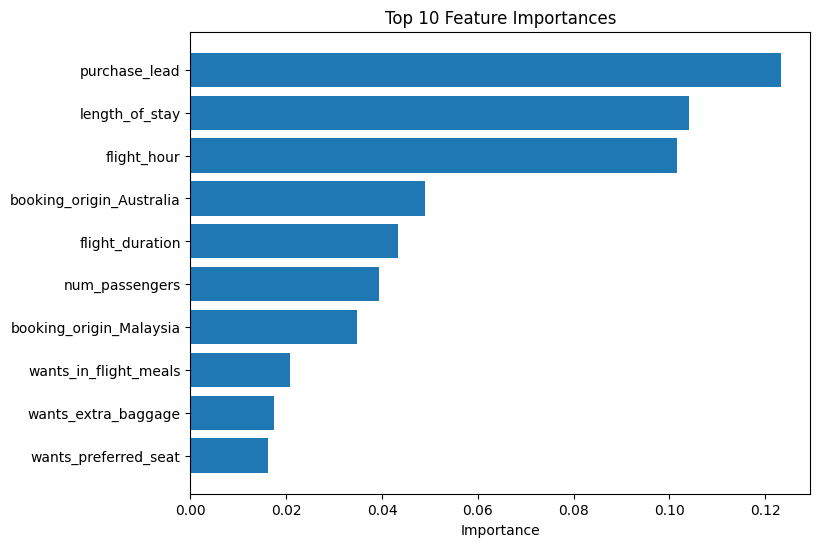

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance.head(10))

plt.figure(figsize=(8,6))
plt.barh(importance["Feature"][:10], importance["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

# Business Findings


**Objective**

Develop a machine learning model to predict whether a customer will complete a booking using historical booking data.

**Model**

Random Forest Classifier

**Results**

* **Accuracy**: 85.21%
* **ROC-AUC**: 0.792
* **Precision**: 53%
* **Recall**: 10%

**Key Findings**

* The model achieved **85.21%** **accuracy** and a **ROC-AUC of 0.792**, indicating good overall predictive performance.

* The dataset is **imbalanced** (85% non-bookings vs. 15% bookings), which resulted in low recall for completed bookings.
* **Purchase lead, length of stay**, and **flight hour** were the most influential predictors of booking completion.
* Customer preferences such as **in-flight meals, extra baggage**, and **preferred seats** also contributed to predicting booking behavior.

**Business Recommendations**

* Target customers based on **purchase lead** and **trip characteristics **with personalized promotions.
* Focus marketing efforts on **customer segments** identified by booking origin and ancillary service preferences.
* Improve the model's ability to detect completed bookings by addressing class imbalance through techniques such as resampling or threshold tuning.